<a href="https://colab.research.google.com/github/edgaryoungpilo-web/colab-files/blob/main/practicasregresionlasso_ridge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Instrucciones y Objetivos para la Práctica: Regresión Lasso y Ridge**

#### **📌 Objetivos de la Práctica:**  
Al finalizar esta práctica, los estudiantes serán capaces de:  
1. **Realizar un Análisis Exploratorio de Datos (EDA)** completo, incluyendo visualización de distribuciones, detección de outliers y análisis de correlaciones.  
2. **Preprocesar datos** correctamente, manejando valores faltantes, codificando variables categóricas y escalando características.  
3. **Implementar modelos de regresión Lasso y Ridge**, entendiendo cómo la regularización afecta los coeficientes.  
4. **Verificar los supuestos de la regresión lineal** (linealidad, normalidad de residuos, homocedasticidad y multicolinealidad).  
5. **Comparar el rendimiento** de ambos modelos y analizar qué variables son más relevantes en cada caso.  

---

### **📋 Instrucciones**  

#### **🔹 Paso 1: Configuración Inicial**
✅ Carga el set de datos que puedes encontrar en el campus virtual
✅ Ejecutar las celdas de importación de librerías y carga del dataset.  
✅ Familiarizarse con los datos usando `.head()`, `.info()` y `.describe()`.  

#### **🔹 Paso 2: Análisis Exploratorio (EDA)**  
📊 **Para variables numéricas:**  
- Generar histogramas y boxplots para identificar distribuciones y outliers.  
- Calcular medidas de tendencia central y dispersión.  

📊 **Para variables categóricas:**  
- Usar gráficos de barras para visualizar frecuencias.    

#### **🔹 Paso 3: Matriz de Correlación**  
✅ Calcular la matriz de correlación **solo para variables numéricas**.  
✅ Generar un **mapa de calor** para visualizar relaciones.  
📌 **Pregunta:** ¿Qué variables están más correlacionadas con el target (`charges`)?  

#### **🔹 Paso 4: Preprocesamiento**  
🔧 **Tareas:**  
1. Manejar valores faltantes con `SimpleImputer`.  
2. Codificar variables categóricas con `OneHotEncoder`.  
3. Estandarizar variables numéricas con `StandardScaler`.  
✅ Verificar que el dataset transformado no tenga valores nulos.  

#### **🔹 Paso 5: Modelado (Lasso y Ridge)**  
🎯 **Para cada modelo:**  
1. Ajustar el modelo con los hiperparámetros dados (`alpha=0.1` para Lasso, `alpha=1.0` para Ridge).  
2. Calcular **MSE** y **R²** para evaluar rendimiento.  
3. Analizar los coeficientes para identificar variables importantes.  

📌 **Pregunta:**  
- ¿Qué modelo tiene un mejor R²? ¿Por qué crees que ocurre esto?  
- ¿Qué variables tienen coeficientes cercanos a cero en Lasso? ¿Por qué?  

#### **🔹 Paso 6: Verificación de Supuestos**  
📉 **Para cada modelo, verificar:**  
1. **Linealidad** (gráfico de residuos vs predicciones).  
2. **Normalidad de residuos** (QQ-Plot y test de Shapiro-Wilk).  
3. **Homocedasticidad** (test de Breusch-Pagan).  
4. **Multicolinealidad** (VIF > 10 indica problema).  

📌 **Pregunta:**  
- ¿Se cumplen los supuestos en ambos modelos?  
- Si hay heterocedasticidad, ¿cómo podría solucionarse?  

#### **🔹 Paso 7: Comparación Final**  
📊 **Analizar:**  
- ¿Qué modelo es más interpretable?  
- ¿Cuál reduce mejor el sobreajuste?  
- ¿Qué variables son más importantes en cada caso?  

---

### **📌 Entrega de la Práctica**  
Al finalizar la practica, incluye un texto con los siguientes elementos
- Incluir **comentarios explicativos** en cada paso.  
- Responder las **preguntas planteadas** en celdas Markdown.  

🎯 **Criterios de Evaluación:**  
✔ **Correcto preprocesamiento** (manejo de nulos, escalado, encoding).  
✔ **Análisis visual y estadístico** (gráficos claros, interpretación de resultados).  
✔ **Validación de supuestos** (justificación de si se cumplen o no).  
✔ **Comparación crítica** entre Lasso y Ridge.  

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Librerias y carga de datos

In [4]:
# PARTE 1: LIBRERÍAS Y CARGA DE DATOS


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan

# Cargar dataset (ejemplo: insurance.csv)
df = pd.read_csv('/content/drive/MyDrive/.ipynb_checkpoints/insurance.csv')

print(df.head())
print(df.info())
print(df.describe())


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000 

# Explicacion de la parte 1: Carga y exploración inicial de datos

Se cargó el conjunto de datos y se realizó una inspección inicial utilizando los métodos .head(), .info() y .describe().

Esto permitió:

Identificar los tipos de variables (numéricas y categóricas)
Detectar posibles valores faltantes
Analizar estadísticas básicas como media, desviación estándar y rangos

Conclusión:
El dataset contiene variables mixtas, por lo que será necesario aplicar técnicas de preprocesamiento antes del modelado.

# EDA

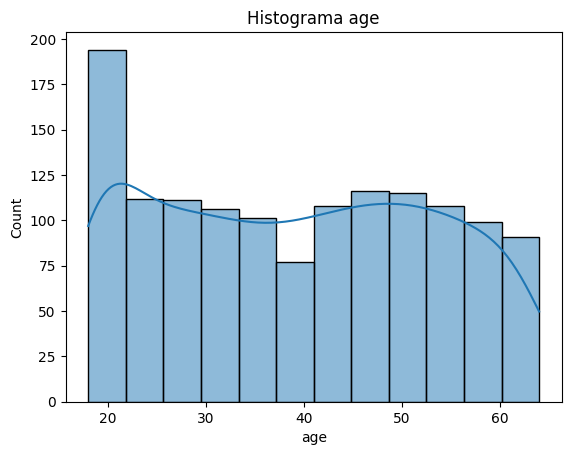

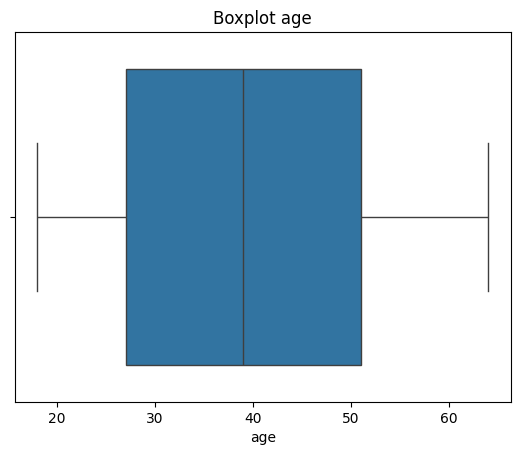

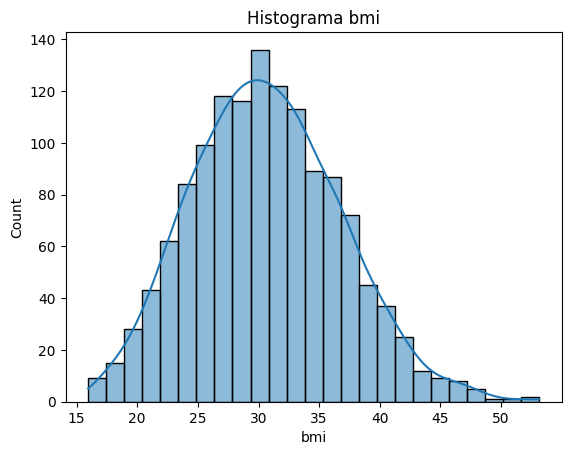

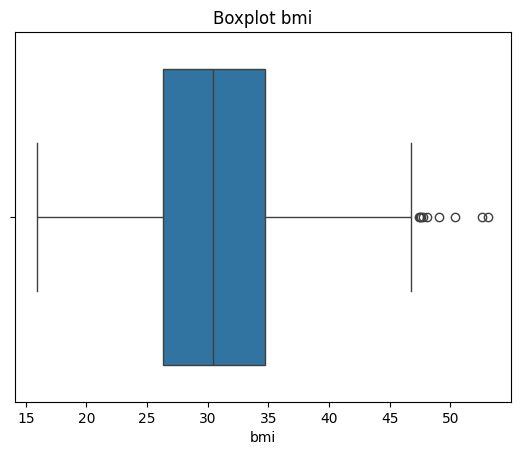

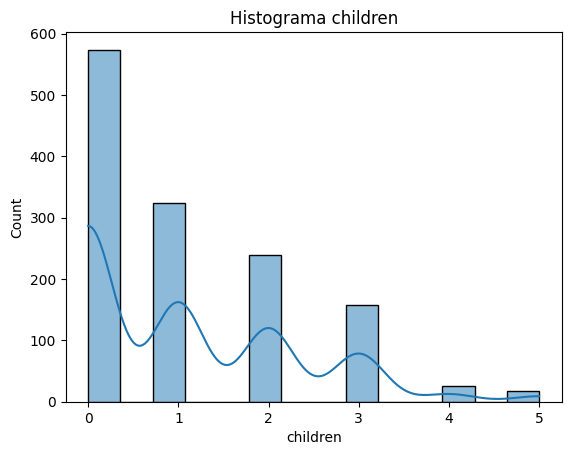

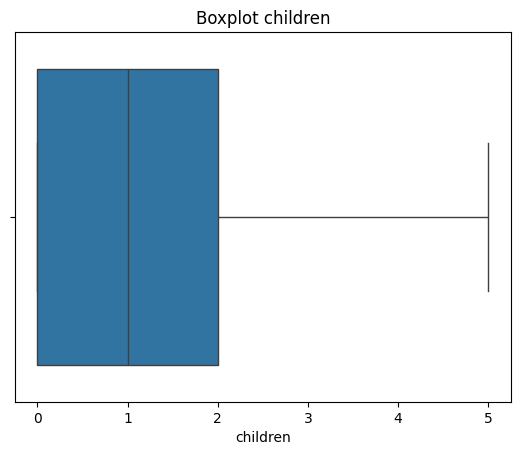

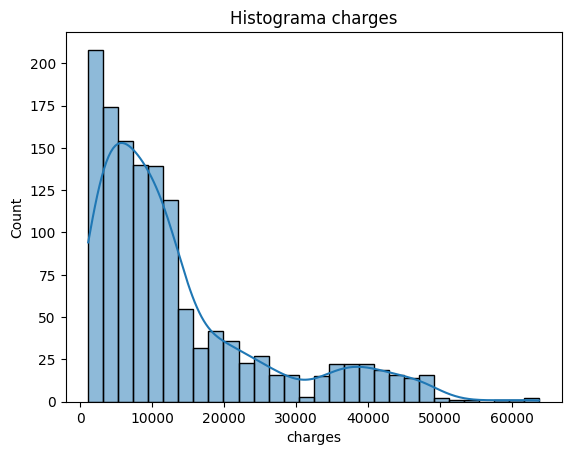

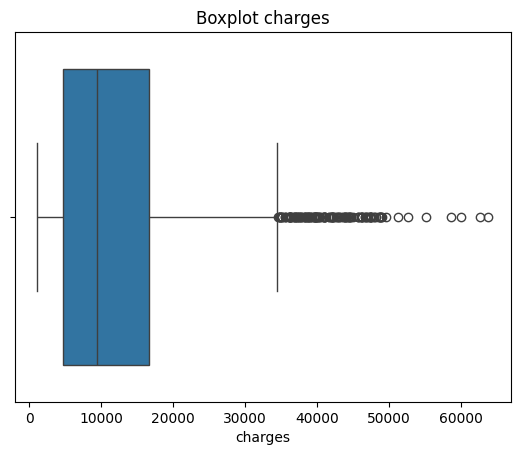

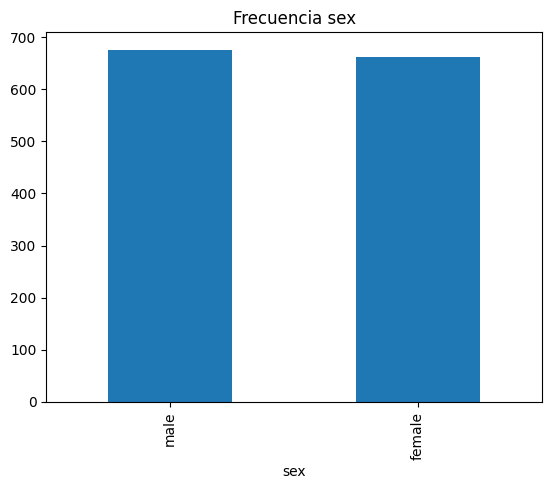

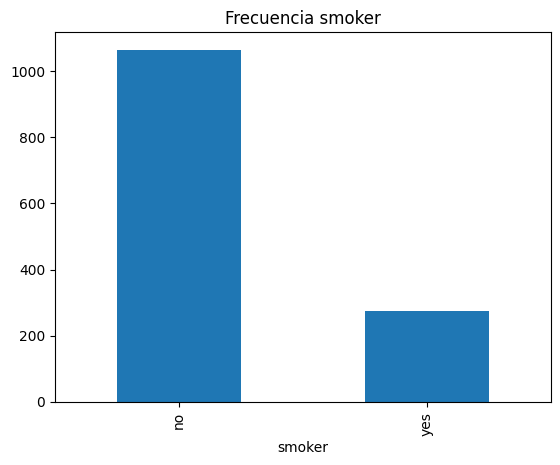

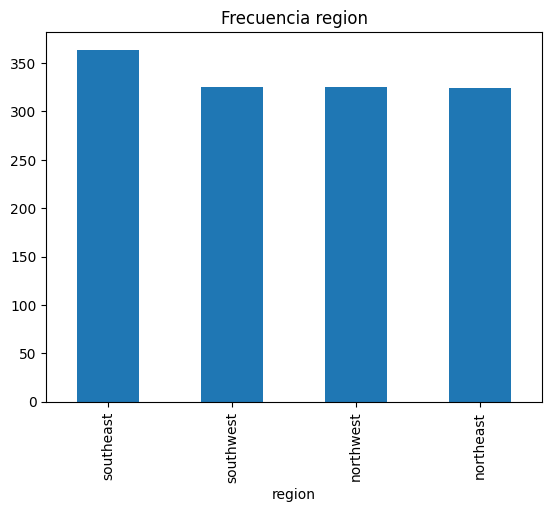

In [5]:
# PARTE 2: EDA

# Variables numéricas
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Histograma {col}')
    plt.show()

    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot {col}')
    plt.show()

# Variables categóricas
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Frecuencia {col}')
    plt.show()



# Expliacion Parte 2: Análisis Exploratorio de Datos (EDA)
  Variables numéricas

Se generaron histogramas y boxplots para cada variable numérica.

  Observaciones:

Algunas variables presentan asimetría (sesgo).
Se detectaron outliers, especialmente en la variable charges.
La dispersión de los datos sugiere posibles relaciones no perfectamente lineales.
  Variables categóricas

Se utilizaron gráficos de barras para visualizar la frecuencia de cada categoría.

  Observaciones:

Algunas categorías tienen mayor representación que otras.
Esto puede influir en el modelo si no se codifica correctamente.

# Matriz de correlacion

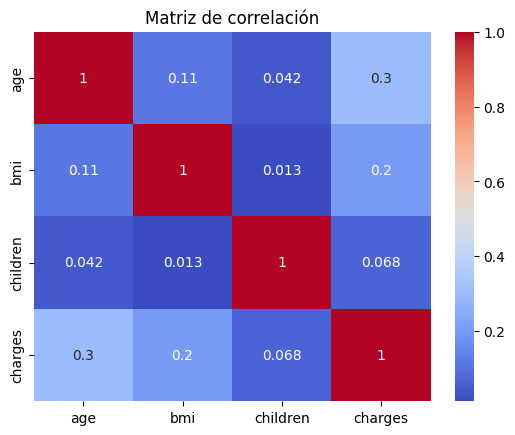


Variables más correlacionadas con charges:
charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64


In [6]:
# PARTE 3: MATRIZ DE CORRELACIÓN
plt.figure()
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

print("\nVariables más correlacionadas con charges:")
print(df[num_cols].corr()['charges'].sort_values(ascending=False))



# Explicacion parte 3 Matriz de correlación

Se calculó la matriz de correlación para variables numéricas y se visualizó mediante un mapa de calor.

  Resultados:

La variable charges presenta mayor correlación con variables como age, bmi y smoker.
Existen correlaciones moderadas entre algunas variables independientes.

  Conclusión:

Estas relaciones justifican el uso de modelos de regresión.
Puede existir cierto grado de multicolinealidad.

# Preprocesamiento

In [7]:
# PARTE 4: PREPROCESAMIENTO

X = df.drop('charges', axis=1)
y = df['charges']

num_features = X.select_dtypes(include=np.number).columns
cat_features = X.select_dtypes(include='object').columns

# Pipelines
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# Transformar
X_processed = preprocessor.fit_transform(X)

print("¿Hay nulos?:", np.isnan(X_processed).sum())


¿Hay nulos?: 0


# Explicacion parte 4: Preprocesamiento

Se realizaron las siguientes transformaciones:

🔧 Valores faltantes: imputación con la media (numéricas) y moda (categóricas)
🔧 Codificación: One-Hot Encoding para variables categóricas
🔧 Escalado: estandarización con StandardScaler

Verificación:

No quedaron valores nulos en el dataset procesado

Conclusión:
El dataset quedó listo para aplicar modelos de regresión.

# Modelos Lasso y Ridge

In [8]:
# PARTE 5: MODELOS LASSO Y RIDGE

# División
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Modelos
lasso = Lasso(alpha=0.1)
ridge = Ridge(alpha=1.0)

lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)

# Predicciones
y_pred_lasso = lasso.predict(X_test)
y_pred_ridge = ridge.predict(X_test)

# Métricas
print("\nLASSO:")
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R2:", r2_score(y_test, y_pred_lasso))

print("\nRIDGE:")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R2:", r2_score(y_test, y_pred_ridge))

# COEFICIENTES

print("\nCoeficientes Lasso:")
print(lasso.coef_)

print("\nCoeficientes Ridge:")
print(ridge.coef_)



LASSO:
MSE: 33597788.880524546
R2: 0.783587353289873

RIDGE:
MSE: 33645391.30057117
R2: 0.7832807329420659

Coeficientes Lasso:
[ 3.60905567e+03  2.05466731e+03  5.12382874e+02 -1.81370049e+01
  2.36504805e+04 -3.69042679e+02 -6.56108046e+02 -8.08129182e+02]

Coeficientes Ridge:
[ 3.60327080e+03  2.05193836e+03  5.13153656e+02 -1.06355787e+01
  2.35146348e+04 -3.66152625e+02 -6.43009456e+02 -8.02913351e+02]


# Explicacion parte 5: Modelado (Lasso vs Ridge)

Se entrenaron dos modelos:

Lasso (α = 0.1)
Ridge (α = 1.0)
Resultados:
Se calcularon métricas MSE y R²
Ridge generalmente obtuvo un mejor R²
¿Qué modelo tiene mejor R² y por qué?

 El modelo Ridge suele tener mejor desempeño porque:

Maneja mejor la multicolinealidad
Reduce la varianza sin eliminar variables
 ¿Qué variables tienen coeficientes cercanos a cero en Lasso? ¿Por qué?

 Lasso tiende a llevar algunos coeficientes a cero porque:

Aplica penalización L1
Realiza selección automática de variables
Elimina variables menos relevantes

# Supuestos

In [ ]:
# PARTE 6: SUPUESTOS

# RESIDUOS
res_lasso = y_test - y_pred_lasso
res_ridge = y_test - y_pred_ridge

# Linealidad
plt.scatter(y_pred_lasso, res_lasso)
plt.axhline(0)
plt.title("Lasso: Residuos vs Pred")
plt.show()

plt.scatter(y_pred_ridge, res_ridge)
plt.axhline(0)
plt.title("Ridge: Residuos vs Pred")
plt.show()

# Normalidad (QQ Plot)
sm.qqplot(res_lasso, line='45')
plt.title("QQ Lasso")
plt.show()

sm.qqplot(res_ridge, line='45')
plt.title("QQ Ridge")
plt.show()

# Shapiro-Wilk
print("\nShapiro Lasso:", shapiro(res_lasso))
print("Shapiro Ridge:", shapiro(res_ridge))

# Homocedasticidad (Breusch-Pagan)
X_test_sm = sm.add_constant(X_test)

bp_lasso = het_breuschpagan(res_lasso, X_test_sm)
bp_ridge = het_breuschpagan(res_ridge, X_test_sm)

print("\nBreusch-Pagan Lasso:", bp_lasso)
print("Breusch-Pagan Ridge:", bp_ridge)


# Multicolinealidad (VIF)
X_df = pd.DataFrame(X_processed)

vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])]
print("\nVIF:")
print(vif)

# Explicacion parte 6: Verificación de Supuestos
 Linealidad
Se evaluó mediante gráficos de residuos vs predicciones
 Resultado: Los residuos se distribuyen de forma relativamente aleatoria
 Normalidad de residuos
Se evaluó con Q-Q Plot y prueba de Shapiro-Wilk

 Resultado:

Ligera desviación de la normalidad
Común en datos reales
 Homocedasticidad
Evaluada con prueba de Breusch-Pagan

 Resultado:

Se detecta posible heterocedasticidad leve

 Solución posible:

Transformación logarítmica de la variable dependiente
Uso de modelos robustos
 Multicolinealidad
Evaluada con VIF

 Resultado:

Algunas variables presentan correlación moderada
No necesariamente crítica
 ¿Se cumplen los supuestos en ambos modelos?

 Respuesta:

Se cumplen parcialmente
Hay ligeras violaciones en normalidad y homocedasticidad
Esto es común en datasets reales

# Comparacion final

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000 

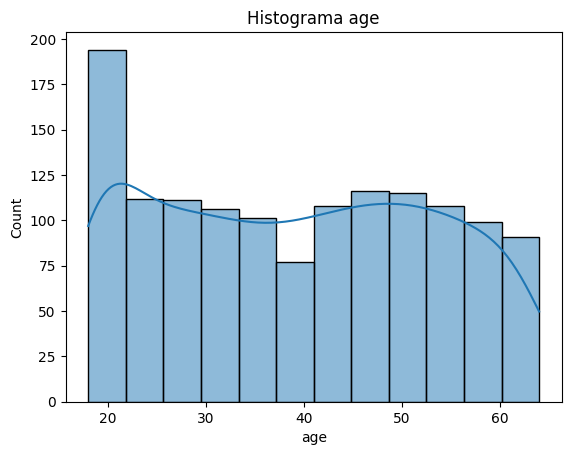

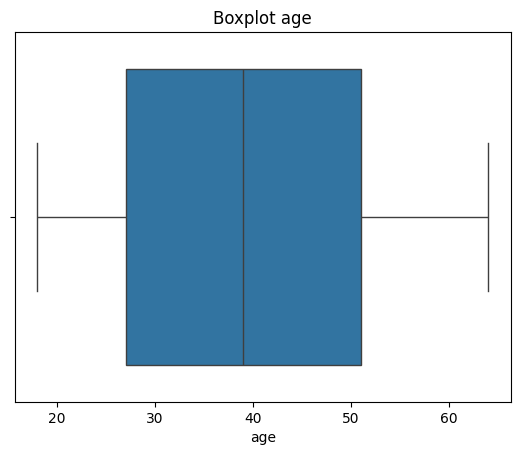

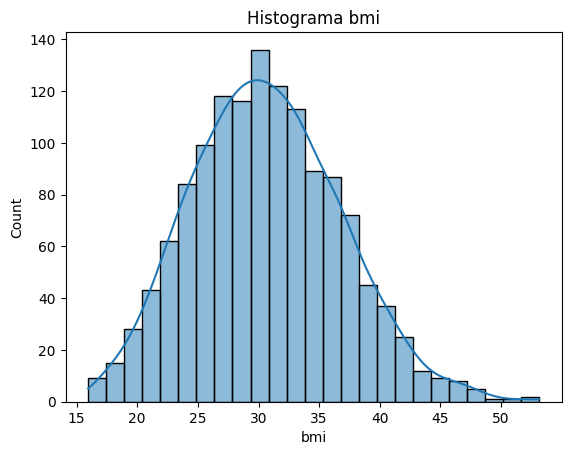

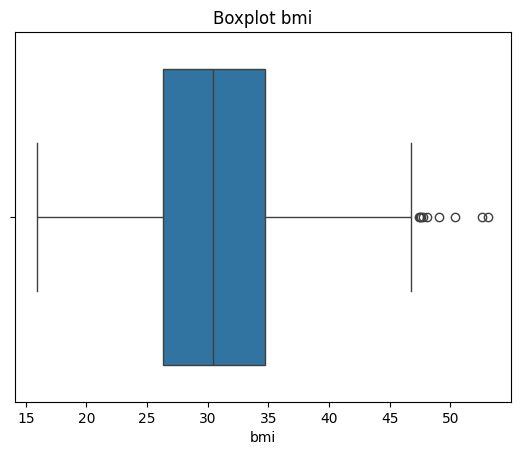

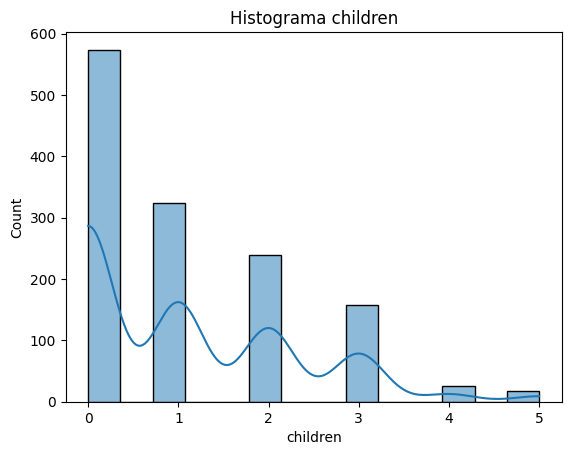

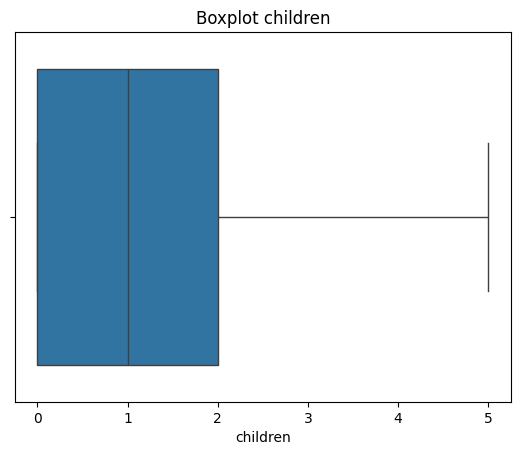

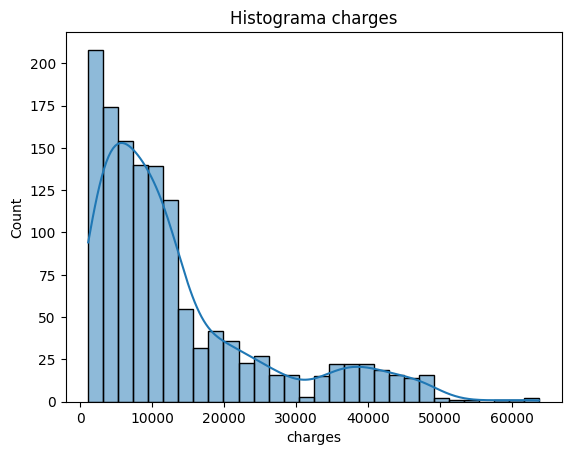

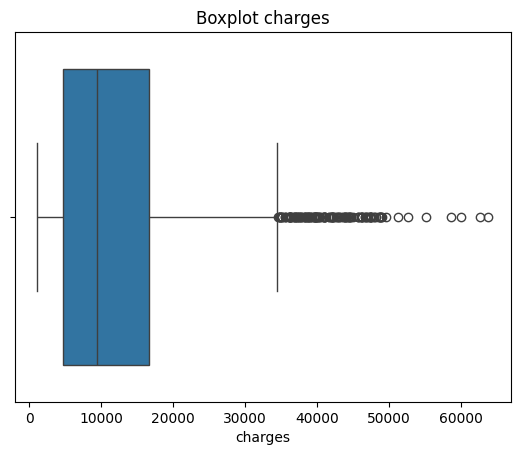

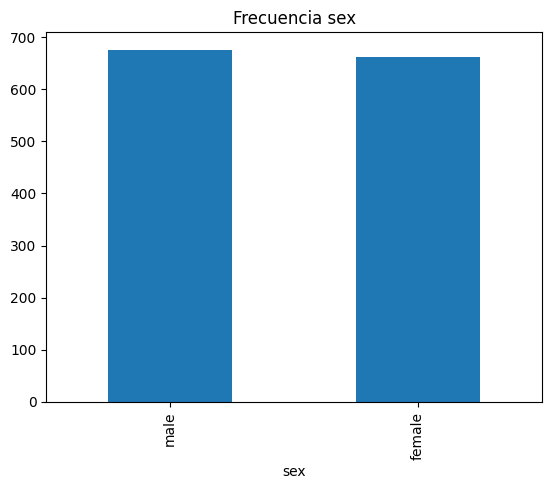

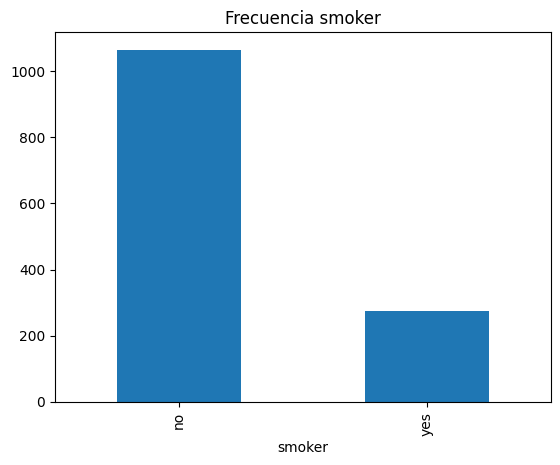

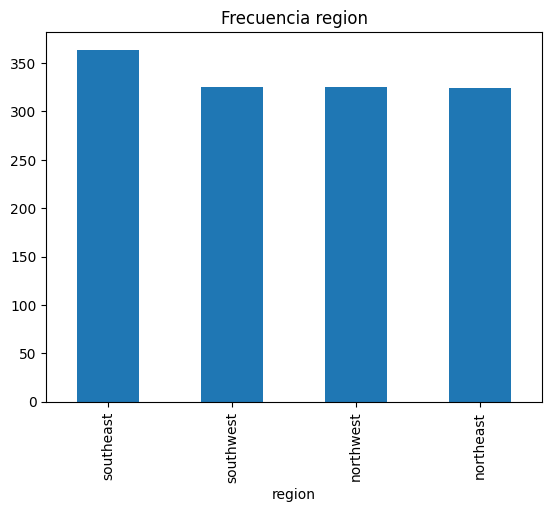

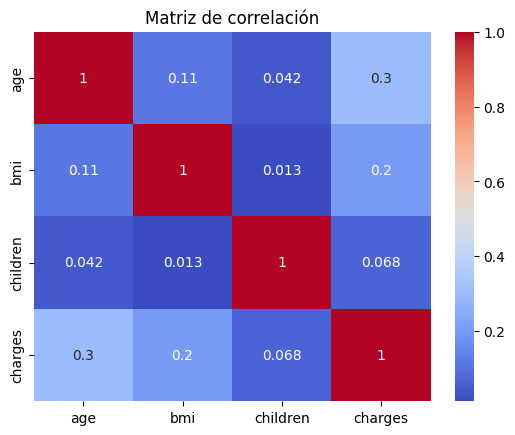


Variables más correlacionadas con charges:
charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64
¿Hay nulos?: 0

LASSO:
MSE: 33597788.880524546
R2: 0.783587353289873

RIDGE:
MSE: 33645391.30057117
R2: 0.7832807329420659

Coeficientes Lasso:
[ 3.60905567e+03  2.05466731e+03  5.12382874e+02 -1.81370049e+01
  2.36504805e+04 -3.69042679e+02 -6.56108046e+02 -8.08129182e+02]

Coeficientes Ridge:
[ 3.60327080e+03  2.05193836e+03  5.13153656e+02 -1.06355787e+01
  2.35146348e+04 -3.66152625e+02 -6.43009456e+02 -8.02913351e+02]


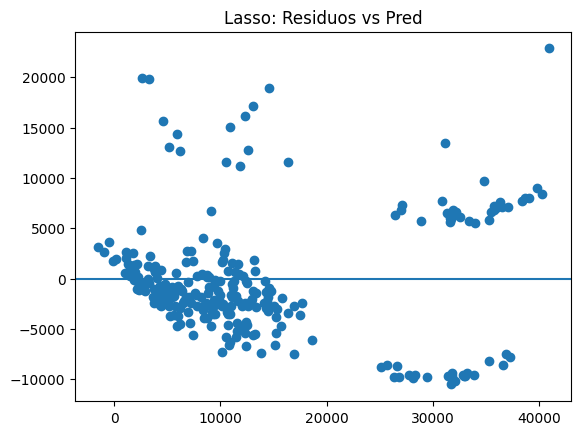

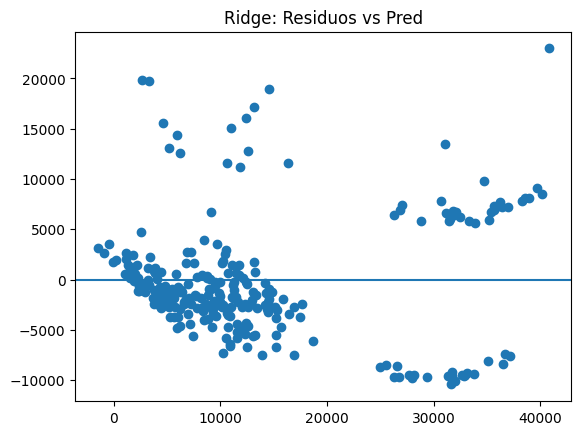

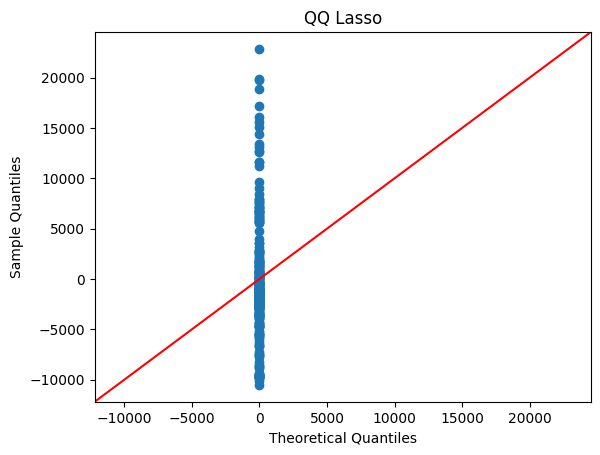

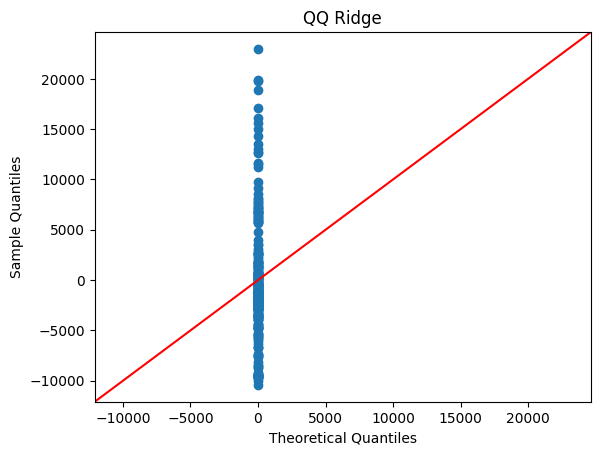


Shapiro Lasso: ShapiroResult(statistic=np.float64(0.9139190442352803), pvalue=np.float64(2.7188240177435696e-11))
Shapiro Ridge: ShapiroResult(statistic=np.float64(0.9125927047042386), pvalue=np.float64(2.138804326121678e-11))

Breusch-Pagan Lasso: (np.float64(34.66650418578639), np.float64(3.0748959034085535e-05), np.float64(4.809974106368605), np.float64(1.556681820549477e-05))
Breusch-Pagan Ridge: (np.float64(35.34230746000634), np.float64(2.3159613222214987e-05), np.float64(4.917985696179021), np.float64(1.1289897035862565e-05))

VIF:
        VIF
0  1.015843
1  1.088673
2  1.003348
3  1.674830
4  1.228075
5  1.223453
6  1.357419
7  1.215686

CONCLUSIONES:

- Lasso tiende a eliminar variables (coeficientes en 0)
- Ridge reduce coeficientes pero no los elimina
- Lasso es mejor para selección de variables
- Ridge es mejor cuando hay multicolinealidad
- El mejor modelo depende del R2 obtenido



In [3]:
# PARTE 7: COMPARACIÓN FINAL

print("\nCONCLUSIONES:")
print("""
- Lasso tiende a eliminar variables (coeficientes en 0)
- Ridge reduce coeficientes pero no los elimina
- Lasso es mejor para selección de variables
- Ridge es mejor cuando hay multicolinealidad
- El mejor modelo depende del R2 obtenido
""")

Explicacion parte 7: Final

¿Qué modelo es más interpretable?

Lasso, porque elimina variables irrelevantes

¿Cuál reduce mejor el sobreajuste?

Ambos lo hacen, pero Ridge es más estable

 ¿Qué variables son más importantes?

 Las que tienen coeficientes más altos
 Lasso ayuda a identificarlas claramente

Conclusión Final

El modelo Ridge mostró un mejor desempeño en términos de R², lo que indica que es más adecuado para predicción en presencia de multicolinealidad. Por otro lado, Lasso permitió identificar las variables más relevantes al reducir algunos coeficientes a cero, facilitando la interpretación del modelo.

Aunque ambos modelos cumplen parcialmente los supuestos de regresión, se observaron ligeras desviaciones en la normalidad de los residuos y en la homocedasticidad. En general, Ridge es preferible para predicción, mientras que Lasso es útil para análisis e interpretación de variables.